# Chapter 6. Planning

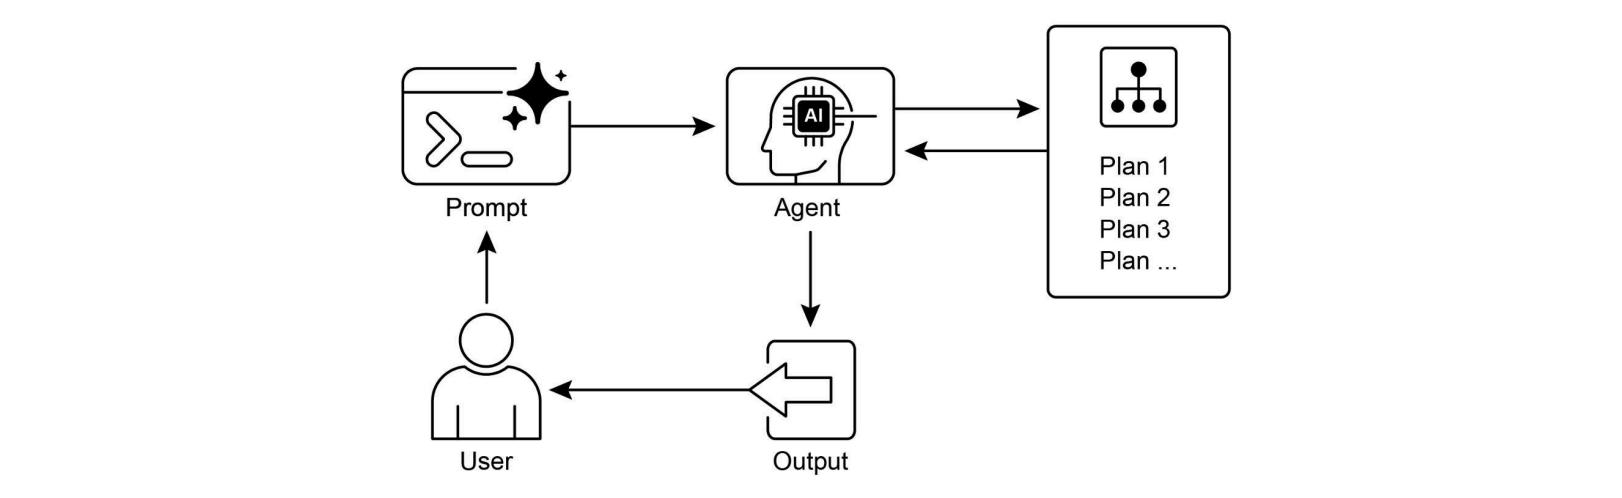

### Core Concept
- **Foresight and Strategy**: Planning is the ability of an agent to create a sequence of actions to reach a goal.
- **The "What" vs. the "How"**: You give the agent an objective (the what), and it autonomously discovers the steps needed (the how).
- **Decomposition**: It involves breaking a large, high-level goal into smaller, manageable sub-goals.

### Why Use It?
- **Complexity**: Standard single-action responses fail when tasks are multi-faceted or have dependencies.
- **Goal-Oriented**: It transforms a reactive system into one that proactively works toward a specific outcome.
- **Adaptability**: Unlike rigid scripts, a planning agent can incorporate new information and steer around obstacles.

### Hands-on Code Example

First, ensure you have the necessary libraries installed:
```
pip install crew
```

In [1]:
import os, logging
from crewai import Agent, Task, Crew, Process, LLM
from dotenv import load_dotenv, find_dotenv
from IPython.display import display, Markdown

load_dotenv(find_dotenv(usecwd=True))
API_KEY  = os.environ.get("API_KEY")
BASE_URL = os.environ.get("BASE_URL")

Initialize the Language Model.

In [2]:
llm = LLM(
    model="glm-5.2",
    api_key=API_KEY,
    base_url=BASE_URL,
    temperature=0
)

Define a clear and focused agent.

- role: Defines the agent’s function and expertise within the crew.
- goal: The individual objective that guides the agent’s decision-making.
- backstory: Provides context and personality to the agent, enriching interactions.
- allow_delegation: Allow the agent to delegate tasks to other agents. Default is False.

In [3]:
agent = Agent(
    role      = "Article Planner and Writer",
    goal      = "Plan and write a concise, engaging summary on  a specified topic.",
    backstory = ("""
        You are an expert technical writer and content strategist.
        Your strength lies in creating a clear, actionable plan before writing, 
        ensuring the final summary is both informative and easy to digest.
    """),
    verbose   = True,
    llm       = llm,
    allow_delegation = False
)

Define a task with a more structured and specific expected output.

In [4]:
topic = "The importance of Reinforcement Learning in AI."
task  = Task(
    description=(
        f"1. Create a bullet-point plan for a summary on the topic: '{topic}'.\n"
        f"2. Write the summary based on your plan, keeping it around 200 words."
    ),
    expected_output=("""
        A final report containing two distinct sections:\n\n
        ### Plan\n
        - A bulleted list outlining the main points of the summary.\n\n
        ### Summary\n
        - A concise and well-structured summary of the topic.
    """),
    agent   = agent,
    markdown= True,
)

Create the creew with a clear process.

- `Process.sequential`: ensures tasks are executed one after the other.
- `Process.hierarchical`: a structured approach to task management, simulating traditional organizational hierarchies for efficient task delegation and execution.

In [5]:
crew = Crew(
    agents  = [agent],
    tasks   = [task],
    process = Process.sequential
)

Execute the task.

- `crew.kickoff()`: start the multiagent execution.

In [6]:
print("Running the planning and writing task.")
# result = crew.kickoff()
result = await crew.kickoff_async()

Running the planning and writing task.


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Article Planner and Writer                                                                              │
│                                                                                                                 │
│  Task: 1. Create a bullet-point plan for a summary on the topic: 'The importance of Reinforcement Learning in   │
│  AI.'.                                                                                                          │
│  2. Write the summary based on your plan, keeping it around 200 words.                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Article Planner and Writer                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Plan                                                                                                       │
│                                                                                                                 │
│  - Brief definition of Reinforcement Learning (RL) and how it works                                             │
│  - Distinction between RL and other machine learning approaches                                                 │
│  - Core components of RL systems (agents, environments, rewards)                                                │
│  - Real-world applications showcasing RL's importance                                                           │
│  - Future implications and current limitations                                                                  │
│  - Conclusion emphasizing RL's role in advancing AGI                                                            │
│                                                                                                                 │
│  ### Summary                                                                                                    │
│                                                                                                                 │
│  # The Importance of Reinforcement Learning in AI                                                               │
│                                                                                                                 │
│  Reinforcement Learning (RL) represents a paradigm where AI agents learn optimal behaviors through              │
│  environmental interaction and feedback. Unlike supervised learning, which requires labeled datasets, RL        │
│  systems discover solutions through trial and error, receiving rewards or penalties based on their actions.     │
│                                                                                                                 │
│  This learning approach mirrors human cognitive development, making it particularly valuable for complex        │
│  decision-making tasks. RL's components—agents, environments, and reward functions—create systems capable of    │
│  mastering sophisticated challenges without explicit programming.                                               │
│                                                                                                                 │
│  The technology's importance is evident in breakthrough applications: DeepMind's AlphaGo defeating world        │
│  champions, autonomous vehicles navigating complex traffic scenarios, and robots learning dexterous             │
│  manipulation tasks. In healthcare, RL optimizes treatment protocols, while in finance, it enhances trading     │
│  strategies.                                                                                                    │
│                                                                                                                 │
│  Despite impressive achievements, RL faces challenges including sample inefficiency, reward specification       │
│  problems, and difficulties with transfer learning. However, ongoing research addressing these limitations      │
│  continues to expand RL's capabilities.                                                                         │
│                                                        

In [8]:
print("--- Task Result ---")
display(Markdown(result.raw))

--- Task Result ---


### Plan

- Brief definition of Reinforcement Learning (RL) and how it works
- Distinction between RL and other machine learning approaches
- Core components of RL systems (agents, environments, rewards)
- Real-world applications showcasing RL's importance
- Future implications and current limitations
- Conclusion emphasizing RL's role in advancing AGI

### Summary

# The Importance of Reinforcement Learning in AI

Reinforcement Learning (RL) represents a paradigm where AI agents learn optimal behaviors through environmental interaction and feedback. Unlike supervised learning, which requires labeled datasets, RL systems discover solutions through trial and error, receiving rewards or penalties based on their actions.

This learning approach mirrors human cognitive development, making it particularly valuable for complex decision-making tasks. RL's components—agents, environments, and reward functions—create systems capable of mastering sophisticated challenges without explicit programming.

The technology's importance is evident in breakthrough applications: DeepMind's AlphaGo defeating world champions, autonomous vehicles navigating complex traffic scenarios, and robots learning dexterous manipulation tasks. In healthcare, RL optimizes treatment protocols, while in finance, it enhances trading strategies.

Despite impressive achievements, RL faces challenges including sample inefficiency, reward specification problems, and difficulties with transfer learning. However, ongoing research addressing these limitations continues to expand RL's capabilities.

As we progress toward artificial general intelligence, RL's ability to learn from environmental feedback rather than human-labeled examples makes it an essential technology. By enabling AI to discover innovative solutions beyond human knowledge, reinforcement learning represents not just an important AI methodology, but potentially the foundation for truly autonomous machine intelligence.